### Perceptrón
2026. MCIB. Raquel Valdés
####Librerías

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

ModuleNotFoundError: No module named 'sklearn'

#### Datos aleatorios

In [ ]:
np.random.seed(7)
X_dummy = np.random.randn(100, 2)
y_dummy = (X_dummy[:, 0] * 1.5 - X_dummy[:, 1] * 0.8 + 0.2 > 0).astype(int)
datos = np.column_stack((X_dummy, y_dummy))

# Separamos las características (X) de la etiqueta (y)
X = datos[:, 0:2]  # Columnas x1 y x2
y = 2*datos[:, 2]-1    # Columna de la etiqueta


In [ ]:
print(y)


[ 1. -1. -1.  1.  1. -1.  1.  1.  1.  1.  1. -1.  1.  1.  1. -1. -1. -1.
 -1.  1.  1.  1. -1. -1.  1.  1.  1.  1. -1. -1.  1. -1.  1. -1.  1.  1.
 -1.  1.  1.  1.  1.  1.  1. -1.  1.  1.  1. -1.  1.  1. -1.  1.  1.  1.
  1. -1.  1. -1.  1. -1.  1.  1. -1.  1.  1. -1. -1.  1.  1. -1. -1.  1.
 -1.  1.  1.  1. -1.  1. -1.  1. -1.  1.  1. -1. -1. -1. -1. -1.  1. -1.
 -1. -1.  1. -1. -1.  1.  1. -1. -1.  1.]


#### Separación de datos en entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=7, stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")


Tamaño del conjunto de entrenamiento: 60 muestras
Tamaño del conjunto de prueba: 40 muestras


####Entrenamiento del perceptrón

In [ ]:

# Construcción del modelo y entrenamiento. tol=1e-3 es el criterio de parada.
modelo = Perceptron(max_iter=1000, tol=1e-3, random_state=10)
modelo.fit(X_train, y_train)

# Recuperamos los pesos (w1, w2) y el sesgo (b) calculados por el Perceptrón
w1, w2 = modelo.coef_[0]
w0 = modelo.intercept_[0]

print(f"\nEcuación de la frontera del Perceptrón: {w1:.4f}*x1 + {w2:.4f}*x2 + {w0:.4f} = 0")

# Evaluar el rendimiento rápido
print(f"Precisión en Entrenamiento: {modelo.score(X_train, y_train) * 100:.1f}%")
print(f"Precisión en Prueba: {modelo.score(X_test, y_test) * 100:.1f}%")


Ecuación de la frontera del Perceptrón: 4.8448*x1 + -1.8232*x2 + 1.0000 = 0
Precisión en Entrenamiento: 96.7%
Precisión en Prueba: 97.5%


####Gráfica de los datos (entrenamiento y prueba)

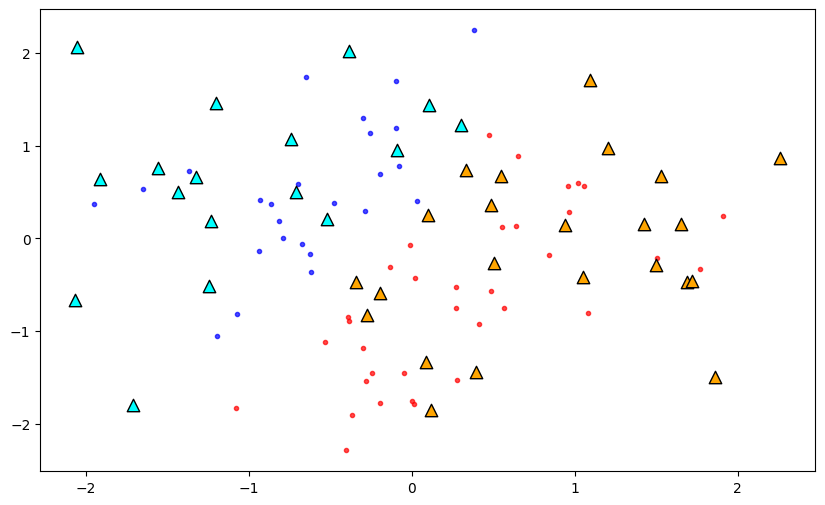

In [ ]:
plt.figure(figsize=(10, 6))

# Entrenamiento (puntos)
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color='blue', marker='.', label='Train - Clase 1', alpha=0.7)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='red', marker='.', label='Train - Clase 2', alpha=0.7)

#Prueba (Triángulos)
plt.scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1], color='cyan', marker='^', edgecolor='black', label='Test - Clase 1', s=80)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='orange', marker='^', edgecolor='black', label='Test - Clase 2', s=80)



####Datos + Recta de clasificación

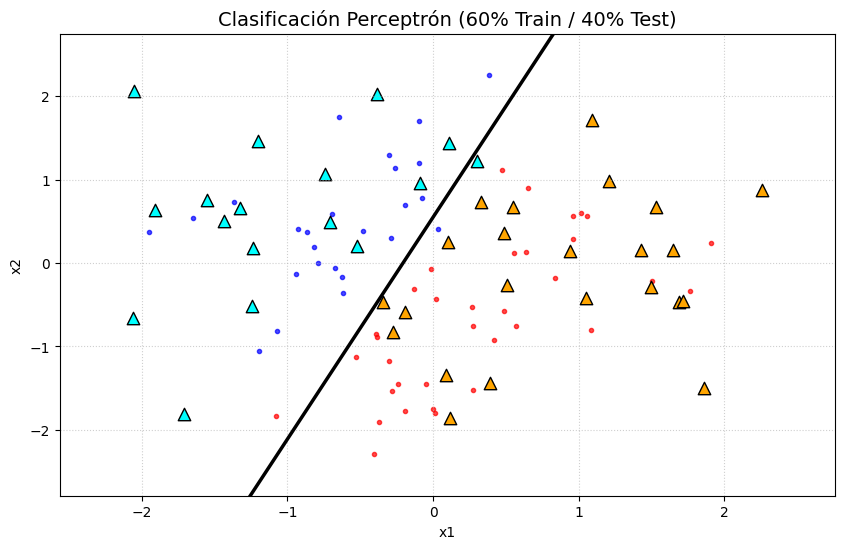

In [ ]:
plt.figure(figsize=(10, 6))

# Dibujar puntos de Entrenamiento (puntos)
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color='blue', marker='.', label='Train - Clase 1', alpha=0.7)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='red', marker='.', label='Train - Clase 2', alpha=0.7)

# Dibujar puntos de Prueba (Triángulos)
plt.scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1], color='cyan', marker='^', edgecolor='black', label='Test - Clase 1', s=80)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='orange', marker='^', edgecolor='black', label='Test - Clase 2', s=80)

# Despejando x2: x2 = -(w1 * x1 + b) / w2
x1_valores = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
x2_valores = -(w1 * x1_valores + w0) / w2

# Dibujar la recta hallada por el Perceptrón
plt.plot(x1_valores, x2_valores, color='black', linestyle='-', linewidth=2.5, label='Recta del Perceptrón')

# Detalles estéticos
plt.title('Clasificación Perceptrón (60% Train / 40% Test)', fontsize=14)
plt.xlabel('x1')
plt.ylabel('x2')
plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
#plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()